# Risk-Neutral Pricing Framework and SDE Discretization Schemes

## 1. The Risk-Neutral Pricing Framework

In the context of modern financial engineering, derivative valuation is grounded in the First Fundamental Theorem of Asset Pricing. This theorem states that the absence of arbitrage is mathematically equivalent to the existence of an equivalent martingale measure, commonly referred to as the **risk-neutral measure** $\mathbb{Q}$. Under this measure, the discounted prices of all risky assets are martingales.

Let $(\Omega, \mathcal{F}, \{\mathcal{F}_t\}_{t \in [0,T]}, \mathbb{Q})$ be a filtered probability space. If we choose the money market account $B_t = \exp\left(\int_0^t r_s ds\right)$ as our numéraire, the arbitrage-free price $V_0$ of a European-style derivative with a terminal payoff $\Phi(S_T)$ at maturity $T$ is given by its discounted expected value under $\mathbb{Q}$:

$$V_0 = \mathbb{E}^{\mathbb{Q}}\left[ \exp\left(-\int_0^T r_t dt\right) \Phi(S_T) \middle| \mathcal{F}_0 \right]$$

Assuming a constant instantaneous risk-free rate $r$ and no continuous dividend yield, the underlying asset dynamics $S_t$ under the risk-neutral measure follow a Geometric Brownian Motion (GBM):

$$dS_t = r S_t dt + \sigma S_t dW_t^{\mathbb{Q}}$$

where $W_t^{\mathbb{Q}}$ is a standard Brownian motion under $\mathbb{Q}$, and $\sigma$ represents the instantaneous volatility.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Standard plot formatting for academic style
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'text.usetex': False,
    'axes.grid': True,
    'grid.alpha': 0.3
})

def black_scholes_call(S0, K, T, r, sigma):
    """
    Analytical price of a European Call option via Black-Scholes formula.
    Used as a theoretical benchmark for convergence.
    """
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# Global model parameters
S0 = 100.0       # Initial spot price
K = 100.0        # Strike price
T = 1.0          # Time to maturity (years)
r = 0.05         # Risk-free interest rate
sigma = 0.20     # Annualized volatility
N_paths = 5000   # Number of simulated Monte Carlo paths
M_steps = 252    # Discretization steps (e.g., trading days in a year)

exact_bs_price = black_scholes_call(S0, K, T, r, sigma)
print(f"Analytical Black-Scholes Price: {exact_bs_price:.4f}")

Analytical Black-Scholes Price: 10.4506


## 2. SDE Discretization Schemes

When the risk-neutral expectation cannot be computed in closed form (e.g., for path-dependent or high-dimensional basket options), we rely on Monte Carlo simulation. This requires discretizing the continuous-time Stochastic Differential Equation (SDE) over a time grid $0 = t_0 < t_1 < \dots < t_M = T$, with a uniform step size $\Delta t = T/M$.

Let us consider a general Itô process of the form $dS_t = \mu(S_t, t) dt + \sigma(S_t, t) dW_t$. We will evaluate three fundamental numerical schemes for financial implementation.

### 2.1 The Euler-Maruyama Scheme
The Euler-Maruyama scheme is the stochastic extension of the Euler method for ODEs. Truncating the stochastic Taylor-Itô expansion at the first order, the local approximation is:

$$S_{t+\Delta t} = S_t + \mu(S_t, t) \Delta t + \sigma(S_t, t) \sqrt{\Delta t} Z$$

where $Z \sim \mathcal{N}(0,1)$. Applied to our GBM under $\mathbb{Q}$, the scheme becomes:

$$S_{t+\Delta t} = S_t + r S_t \Delta t + \sigma S_t \sqrt{\Delta t} Z$$

This scheme exhibits a **strong convergence order of 0.5**, making it highly susceptible to discretization error (time-stepping bias) if $\Delta t$ is not sufficiently small.

### 2.2 The Milstein Scheme
To achieve a higher **strong convergence order of 1.0**, the Milstein scheme incorporates the second-order term derived from stochastic Itô integration:

$$S_{t+\Delta t} = S_t + \mu(S_t, t) \Delta t + \sigma(S_t, t) \sqrt{\Delta t} Z + \frac{1}{2} \sigma(S_t, t) \frac{\partial \sigma(S_t, t)}{\partial S} \Delta t \left(Z^2 - 1\right)$$

For the GBM, where the diffusion coefficient is $\sigma(S_t, t) = \sigma S_t$, the partial derivative with respect to $S$ is simply $\sigma$. Consequently, the scheme reduces to:

$$S_{t+\Delta t} = S_t + r S_t \Delta t + \sigma S_t \sqrt{\Delta t} Z + \frac{1}{2} \sigma^2 S_t \Delta t \left(Z^2 - 1\right)$$

This corrective term adjusts for the convexity introduced by the stochastic nature of the diffusion process.

### 2.3 The Exact Scheme (GBM)
In the specific case of Geometric Brownian Motion with constant coefficients, discretization error can be eliminated entirely. By applying Itô's Lemma to the logarithmic transformation $f(S_t) = \ln(S_t)$, we obtain a linear SDE with constant drift. Integrating directly between $t$ and $t+\Delta t$ yields the exact exact solution:

$$S_{t+\Delta t} = S_t \exp\left( \left(r - \frac{1}{2}\sigma^2\right)\Delta t + \sigma \sqrt{\Delta t} Z \right)$$

This approach guarantees that the simulated state variables are drawn from the exact theoretical marginal distribution of the continuous process, regardless of the step size $\Delta t$.

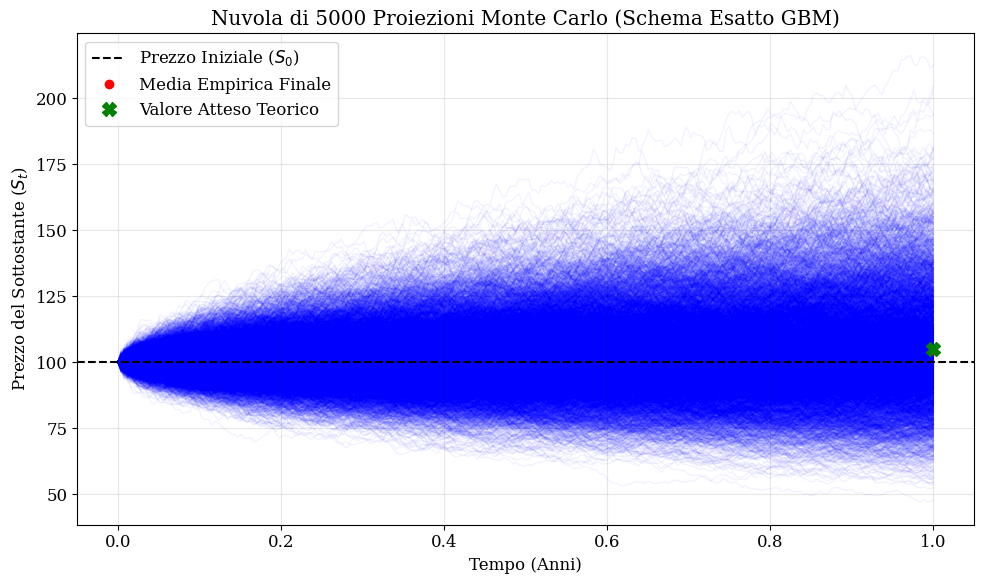

In [6]:
import matplotlib.pyplot as plt

# Creiamo un grafico della "nuvola di proiezioni" per lo Schema Esatto
plt.figure(figsize=(10, 6))

# Creiamo l'asse dei tempi
time_grid = np.linspace(0, T, M_steps + 1)

# Plottiamo tutte le traiettorie
# Usiamo un livello di trasparenza (alpha) basso per evitare che il grafico sia illeggibile
plt.plot(time_grid, paths_exact, color='blue', alpha=0.05, linewidth=1)

# Evidenziamo il prezzo iniziale e la media finale
plt.axhline(y=S0, color='black', linestyle='--', label='Prezzo Iniziale ($S_0$)')

# Calcoliamo la media dei prezzi finali (Valore atteso sotto Q)
expected_terminal_price = S0 * np.exp(r * T)
plt.plot(T, np.mean(paths_exact[-1]), 'ro', label='Media Empirica Finale')
plt.plot(T, expected_terminal_price, 'gX', markersize=10, label='Valore Atteso Teorico')

plt.title(f'Nuvola di {N_paths} Proiezioni Monte Carlo (Schema Esatto GBM)')
plt.xlabel('Tempo (Anni)')
plt.ylabel('Prezzo del Sottostante ($S_t$)')
plt.grid(True, alpha=0.3)

# Evitiamo di inserire la legenda per ogni singola traiettoria
handles, labels = plt.gca().get_legend_handles_labels()
# Rimuoviamo i duplicati nella legenda causati dal plot multiplo
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.tight_layout()
plt.show()

## 3. Error Analysis and Monte Carlo Estimation

By applying the exact same stochastic innovations $Z$, we can quantitatively isolate the bias introduced by the numerical approximations. We estimate the derivative price (European Call) by approximating the continuous expectation with the empirical sample mean:

$$\hat{V}_0 = e^{-rT} \frac{1}{N} \sum_{i=1}^N \max\left(S_M^{(i)} - K, 0\right)$$

Subsequently, we visualize the behavior of a single stochastic realization under the three different schemes to graphically understand how discretization error compounds over time.

Analytical BS Benchmark: 10.45058
-----------------------------------------------------------------
Euler-Maruyama Estimate: 10.12360 | Absolute Error: 0.32699 | Std Err: 0.20143
Milstein Estimate:       10.12243 | Absolute Error: 0.32816 | Std Err: 0.20147
Exact Scheme Estimate:   10.12415 | Absolute Error: 0.32643 | Std Err: 0.20151


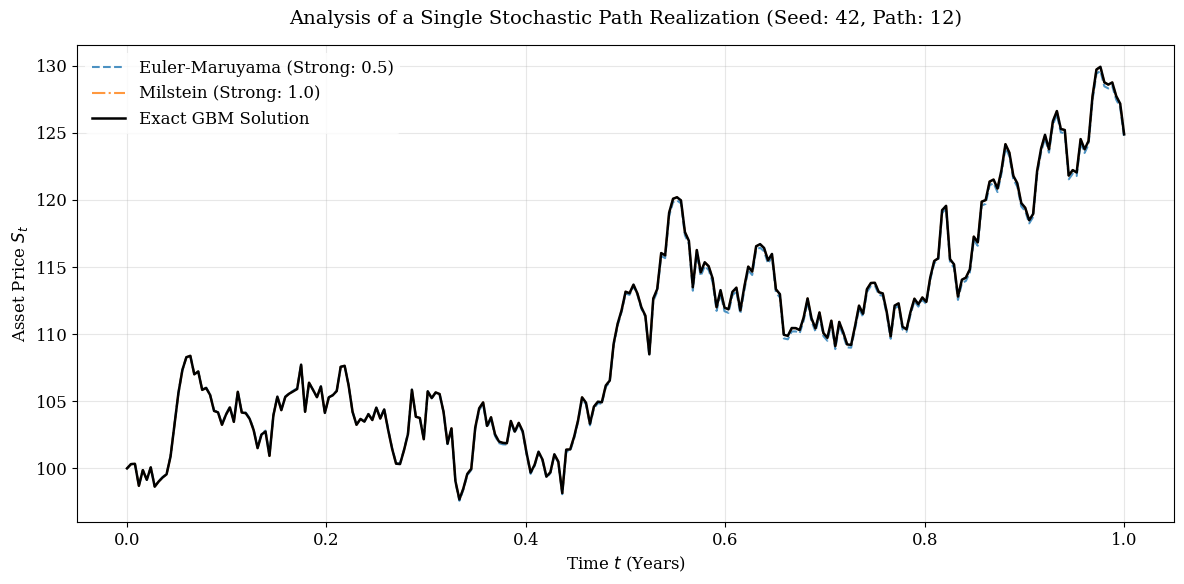

In [5]:
def evaluate_mc_price(paths, K, T, r):
    """Calculates the Monte Carlo estimated price and its standard error."""
    terminal_prices = paths[-1]
    payoffs = np.maximum(terminal_prices - K, 0)
    discounted_payoffs = np.exp(-r * T) * payoffs
    
    price = np.mean(discounted_payoffs)
    std_err = np.std(discounted_payoffs) / np.sqrt(len(discounted_payoffs))
    return price, std_err

price_euler, err_euler = evaluate_mc_price(paths_euler, K, T, r)
price_milstein, err_milstein = evaluate_mc_price(paths_milstein, K, T, r)
price_exact, err_exact = evaluate_mc_price(paths_exact, K, T, r)

print("="*65)
print(f"Analytical BS Benchmark: {exact_bs_price:.5f}")
print("-"*65)
print(f"Euler-Maruyama Estimate: {price_euler:.5f} | Absolute Error: {abs(price_euler - exact_bs_price):.5f} | Std Err: {err_euler:.5f}")
print(f"Milstein Estimate:       {price_milstein:.5f} | Absolute Error: {abs(price_milstein - exact_bs_price):.5f} | Std Err: {err_milstein:.5f}")
print(f"Exact Scheme Estimate:   {price_exact:.5f} | Absolute Error: {abs(price_exact - exact_bs_price):.5f} | Std Err: {err_exact:.5f}")
print("="*65)

# Comparative plot of the stochastic paths
plt.figure(figsize=(12, 6))
t_grid = np.linspace(0, T, M_steps + 1)
path_idx = 12  # Select a specific path realization to examine

plt.plot(t_grid, paths_euler[:, path_idx], label='Euler-Maruyama (Strong: 0.5)', linestyle='--', alpha=0.8)
plt.plot(t_grid, paths_milstein[:, path_idx], label='Milstein (Strong: 1.0)', linestyle='-.', alpha=0.8)
plt.plot(t_grid, paths_exact[:, path_idx], label='Exact GBM Solution', color='black', linewidth=1.8)

plt.title(f'Analysis of a Single Stochastic Path Realization (Seed: {seed_value}, Path: {path_idx})', fontsize=14, pad=15)
plt.xlabel('Time $t$ (Years)', fontsize=12)
plt.ylabel('Asset Price $S_t$', fontsize=12)
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()